In [ ]:
%pip install kagglehub

In [3]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import urllib.request
import zipfile

In [ ]:
class KaggleDatasetDownloader:
    def __init__(self, links, base_dir="Datasets"):
        self.links = links
        self.base_dir = os.path.abspath(base_dir)

    def download(self):
        os.makedirs(self.base_dir, exist_ok=True)

        for dataset in self.links:
            print(f"\nDownloading: {dataset}")
            path = kagglehub.dataset_download(dataset)

            dataset_name = dataset.split('/')[-1]
            save_dir = os.path.join(self.base_dir, dataset_name)
            os.makedirs(save_dir, exist_ok=True)

            print(f"Saving to: {save_dir}")

            for file in os.listdir(path):
                if file.endswith(".csv"):
                    print(f"  → {file}")
                    df = pd.read_csv(os.path.join(path, file), low_memory=False)
                    df.to_csv(os.path.join(save_dir, file), index=False)

        print("\nAll datasets saved successfully!")

    def add_dataset(self, dataset_link):
        self.links.append(dataset_link)

In [ ]:
links = [
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews",
    "rounakbanik/the-movies-dataset"
]

downloader = KaggleDatasetDownloader(links)

# Run whenever you want
#downloader.download()

# Add more datasets later
# downloader.add_dataset("new/dataset-link")
# downloader.download()

In [ ]:
# 1. Define the URL and your save directories
url = "https://files.grouplens.org/datasets/movielens/ml-25m.zip"
base_save_dir = os.path.abspath("Datasets")
dataset_name = "movielens-25m"

# Create the dedicated folder: CINEIQ\Datasets\movielens-25m
save_dir = os.path.join(base_save_dir, dataset_name)
os.makedirs(save_dir, exist_ok=True)

zip_path = os.path.join(save_dir, "ml-25m.zip")

# 2. Download the file
# Note: This file is ~250MB, so it might take a minute or two depending on your internet speed.
print("Please wait, this might take a moment...")
urllib.request.urlretrieve(url, zip_path)
print("Download complete!")

# 3. Extract the contents of the Zip file
print("Extracting CSV files...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for member in zip_ref.namelist():
        # Remove the top-level folder (ml-25m/)
        filename = os.path.basename(member)

        if filename:  # skip directories
            source = zip_ref.open(member)
            target_path = os.path.join(save_dir, filename)

            with open(target_path, "wb") as target:
                target.write(source.read())



In [ ]:
import os
import requests

url = "https://files.grouplens.org/datasets/movielens/ml-25m.zip"

base_save_dir = os.path.abspath("Datasets")
dataset_name = "movielens-25m"

save_dir = os.path.join(base_save_dir, dataset_name)
os.makedirs(save_dir, exist_ok=True)

zip_path = os.path.join(save_dir, "ml-25m.zip")

print("Downloading...")

try:
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()

        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

    print("Download complete!")

except Exception as e:
    print("Download failed:", e)
    print("Try again or change network (mobile hotspot recommended)")

In [4]:
folder_path=r"C:\Users\Khusi Patra\Desktop\Projects\Coding club\CINEIQ\Datasets\the-movies-dataset\{}.csv"
files=['credits','keywords','links','links_small','movies_metadata','ratings_small','ratings']
dataframes={}
for file in files:
    dataframes[file] = pd.read_csv(folder_path.format(file),low_memory=False)
   

In [5]:
folder_path=r"C:\Users\Khusi Patra\Desktop\Projects\Coding club\CINEIQ\Datasets\movielens-25m\{}.csv"
files=['movies','genome-tags','genome-scores']
dataframes2={}
for file in files:
    dataframes2[file] = pd.read_csv(folder_path.format(file),low_memory=False)
   

## IMDB 
1. IMDB dataset has response(positive/negetive) of movie with shape (50000, 2) no id 

## the-movies datset 
1. credit(45476, 3) and keywords(46419, 2) and movies_metadata(45466, 24) has a column id on which we can merge 
2. links_small (9125, 3) and links(45843, 3) has a tmdbId which is same as id of credit
3. links has shape (45843, 3) and links_small has shape (9125, 3)
4. ratings_small has a column movieid on which we can merge shape (100004, 4) 
5. rating has a column movieid shape (26024289, 4) can stack with ratings_small

## 

In [6]:
credits_df=dataframes['credits']
keywords_df=dataframes['keywords']
links_df=dataframes['links']
links_small_df=dataframes['links_small']
movies_metadata_df=dataframes['movies_metadata']
ratings_df=dataframes['ratings']
ratings_small_df=dataframes['ratings_small']
movies_df=dataframes2['movies']
genome_tags_df=dataframes2['genome-tags']
genome_scores_df=dataframes2['genome-scores']

In [7]:
movies_df

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
62418,209157,We (2018),Drama
62419,209159,Window of the Soul (2001),Documentary
62420,209163,Bad Poems (2018),Comedy|Drama
62421,209169,A Girl Thing (2001),(no genres listed)


In [8]:
credits_df.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [9]:
keywords_df.head()

,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


In [10]:
links_small_df.shape

(9125, 3)

In [11]:
movies_metadata_df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [12]:
combined_links = pd.concat([links_df, links_small_df], axis=0, ignore_index=True)

In [13]:
combined_links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [14]:
combined_links.shape

(54968, 3)

In [15]:
combined_ratings = pd.concat([ratings_df, ratings_small_df], axis=0, ignore_index=True)

In [16]:
combined_ratings.shape

(26124293, 4)

In [17]:
combined_ratings.head()

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435
2,1,858,5.0,1425941523
3,1,1221,5.0,1425941546
4,1,1246,5.0,1425941556


In [18]:
combined_links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [19]:
movies_metadata_df["id"] = pd.to_numeric(movies_metadata_df["id"], errors="coerce")

In [20]:
df = credits_df.merge(keywords_df,on="id", how="outer") \
        .merge(combined_links, left_on="id", right_on="tmdbId", how="outer") \
        .merge(movies_metadata_df,on="id", how="outer")

## **Basic Info About All Columns In Data**

1. `cast` has info about all actors.
2. `crew` has info about who have done all the production work.
3. Here `id`  and `tmdbId` has same id of a movie.
4. `keywords` contains tags that describe the themes or important ideas in the movie.
5. `imdbId` and `imdb_id` both are same but `imdb_id` is in right format(tt0094675) and it has some missing values so we can fill it from `imdbId`(only 1 missing values) and then we can drop `imdbId`.
6. `belongs_to_collection` column tells whether a movie is part of a series/franchise and gives the name of that collection(that's why the column has less value as all movie are not a part of series).But in some place it has some weird number that is the data is corrupted.
7. `budget` column contain info about total amount spent to produce that movie but this column also has some corrupted value.
8. `genres` has info that what type/category this movie belong to.
9. `homepage` has info about Official website URL of the movie and also in some row it contain the value which should be in `production_country` column(so we need to extract them).
10. `original_language` has info about in which language this movie is.but it contain some weired number which may be data of different column(need checking).
11. `original_title` has the title(real name of the movie in which language it is made) of the movie here in some row we have value of `spoken_language` column so the columns are mixed and also we have repeated name so need checking that are they same movie or different version of same movie.
12. `overview` has brief movie description but it is mixed up with status column as it has 'released' as value which should be in `status` column.
13. `popularity` column has scores that how popular this movie is but it is mixed up with may be `tagline` column as in some place has value like 'Beware Of Frost Bites'.
14. `production_companies` has info company name it has also value like 'False' in many rows which need to be corrected.
15. `adult` should contain two values 'False'(normal movie) and 'True' (adult movie:for 18+years) but in some places it have text(may be from overview column) like 3 text each 424 times(need checking).
16. `production_countries` give info that which country produce that movie.
17. `release_date` has info when the movie is released it is also corrupted as (12,1,22 this 3 value contain each 424 times and this colulmn also has lot of missing values).
18. `revenue` give info that how much money the movie earned (it has a lot of 0 values(43676) and nan values also)(need cleaning).
19. `runtime` contain total movie time(in min).
20. `spoken_language` contain info that what all language used in this movie.
21. `status` give current statge of movies lifecycle(so from here we have to show only those movies which are released for recomendation).
22. `tagline` is basically a short promotional sentence for marketing.
23. `title` has title(standerdized title(baiscally in english)) of the movie but it has many repeated values(so need checking are they really same movie or not).so we may be merge this column with 'original_title' column after cleaning and use that column in tf_idf.
24. `video` has info about the movie trailor availabilty in this dataset(so only two values False and True)(not usefull for TfIdf may be used for filltering).
25. `vote_average` give average rating score of that movie.
26. `vote_count` give how many users rated that movie. here we can merge this two column for filltering the movie after TfIdf.
* **`cast`,`crew`,`keywords`,`belongs_to_collection`,`genres`,`production_companies`,
`production_countries`,`spoken_language` all are in string format first need to parse them to make a list of dictionary for extract info from it.**

In [21]:
#missing value percentage in each column
(df.isnull().mean() * 100).to_frame().T

,cast,crew,id,keywords,movieId,imdbId,tmdbId,adult,belongs_to_collection,budget,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,2.217693,2.217693,2.215951,2.217693,0.001742,0.001742,1.214243,0.0,86.826243,0.0,...,0.153305,2.222919,2.682833,2.222919,2.369255,51.236891,2.222919,2.222919,2.222919,2.222919


In [22]:
df[df.duplicated(keep=False)]

,cast,crew,id,keywords,movieId,imdbId,tmdbId,adult,belongs_to_collection,budget,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,"[{'cast_id': 3, 'character': 'Taisto Olavi Kas...","[{'credit_id': '52fe420dc3a36847f800001f', 'de...",2.0,"[{'id': 240, 'name': 'underdog'}, {'id': 378, ...",4470.0,94675.0,2.0,False,NaN,0,...,1988-10-21,0.0,69.0,"[{'iso_639_1': 'fi', 'name': 'suomi'}, {'iso_6...",Released,NaN,Ariel,False,7.1,44.0
1,"[{'cast_id': 3, 'character': 'Taisto Olavi Kas...","[{'credit_id': '52fe420dc3a36847f800001f', 'de...",2.0,"[{'id': 240, 'name': 'underdog'}, {'id': 378, ...",4470.0,94675.0,2.0,False,NaN,0,...,1988-10-21,0.0,69.0,"[{'iso_639_1': 'fi', 'name': 'suomi'}, {'iso_6...",Released,NaN,Ariel,False,7.1,44.0
3,"[{'cast_id': 42, 'character': 'Ted the Bellhop...","[{'credit_id': '52fe420dc3a36847f800011b', 'de...",5.0,"[{'id': 612, 'name': 'hotel'}, {'id': 613, 'na...",18.0,113101.0,5.0,False,NaN,4000000,...,1995-12-09,4300000.0,98.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Twelve outrageous guests. Four scandalous requ...,Four Rooms,False,6.5,539.0
4,"[{'cast_id': 42, 'character': 'Ted the Bellhop...","[{'credit_id': '52fe420dc3a36847f800011b', 'de...",5.0,"[{'id': 612, 'name': 'hotel'}, {'id': 613, 'na...",18.0,113101.0,5.0,False,NaN,4000000,...,1995-12-09,4300000.0,98.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Twelve outrageous guests. Four scandalous requ...,Four Rooms,False,6.5,539.0
5,"[{'cast_id': 7, 'character': 'Frank Wyatt', 'c...","[{'credit_id': '52fe420dc3a36847f800023d', 'de...",6.0,"[{'id': 520, 'name': 'chicago'}, {'id': 2231, ...",479.0,107286.0,6.0,False,NaN,0,...,1993-10-15,12136938.0,110.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Don't move. Don't whisper. Don't even breathe.,Judgment Night,False,6.4,79.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57388,NaN,NaN,NaN,NaN,73759.0,495212.0,NaN,Rune Balot goes to a casino connected to the ...,1.931659,/zV8bHuSL6WXoD6FWogP9j4x80bL.jpg,...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57389,NaN,NaN,NaN,NaN,73759.0,495212.0,NaN,Avalanche Sharks tells the story of a bikini ...,2.185485,/zaSf5OG7V8X8gqFvly88zDdRm46.jpg,...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57390,NaN,NaN,NaN,NaN,79299.0,874957.0,NaN,- Written by Ørnås,0.065736,/ff9qCepilowshEtG2GYWwzt2bs4.jpg,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57391,NaN,NaN,NaN,NaN,79299.0,874957.0,NaN,Rune Balot goes to a casino connected to the ...,1.931659,/zV8bHuSL6WXoD6FWogP9j4x80bL.jpg,...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df[['genres','movieId','title','tmdbId']].head(6)

,genres,movieId,title,tmdbId
0,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",4470.0,Ariel,2.0
1,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",4470.0,Ariel,2.0
2,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",61724.0,Shadows in Paradise,3.0
3,"[{'id': 80, 'name': 'Crime'}, {'id': 35, 'name...",18.0,Four Rooms,5.0
4,"[{'id': 80, 'name': 'Crime'}, {'id': 35, 'name...",18.0,Four Rooms,5.0
5,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",479.0,Judgment Night,6.0


In [22]:
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [23]:
# pd.set_option('display.max_columns', None)

# pd.set_option('display.max_colwidth', None)
df['vote_count'].value_counts()

vote_count
1.0       3449
2.0       3294
0.0       3097
3.0       3072
4.0       2647
          ... 
718.0        1
5612.0       1
612.0        1
621.0        1
357.0        1
Name: count, Length: 1820, dtype: int64

In [24]:
df.columns

Index(['cast', 'crew', 'id', 'keywords', 'movieId', 'imdbId', 'tmdbId',
       'adult', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57402 entries, 0 to 57401
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cast                   56129 non-null  object 
 1   crew                   56129 non-null  object 
 2   id                     56130 non-null  float64
 3   keywords               56129 non-null  object 
 4   movieId                57401 non-null  float64
 5   imdbId                 57401 non-null  float64
 6   tmdbId                 56705 non-null  float64
 7   adult                  57402 non-null  object 
 8   belongs_to_collection  7562 non-null   object 
 9   budget                 57402 non-null  object 
 10  genres                 57402 non-null  object 
 11  homepage               11322 non-null  object 
 12  imdb_id                57385 non-null  object 
 13  original_language      57391 non-null  object 
 14  original_title         57402 non-null  object 
 15  ov

In [26]:
print(combined_ratings['movieId'].min())
print(combined_ratings['movieId'].max())

1
176275


In [27]:
print(df['movieId'].min())
print(df['movieId'].max())


1.0
176279.0


In [28]:
combined_ratings.shape

(26124293, 4)

In [29]:
df1=df.copy()

In [35]:
df1[['tmdbId','id']]

,tmdbId,id
0,2.0,2.0
1,2.0,2.0
2,3.0,3.0
3,5.0,5.0
4,5.0,5.0
...,...,...
57397,NaN,NaN
57398,NaN,NaN
57399,NaN,NaN
57400,NaN,NaN


In [33]:
df1['tmdbId'].duplicated().sum()

np.int64(11800)

In [34]:
df1['id'].duplicated().sum()

np.int64(11968)

In [30]:
print(df1['id'].duplicated().sum())
print(df1.duplicated().sum())

11968
10718


In [31]:
df1.drop_duplicates(inplace=True)

In [32]:
print(df1['id'].duplicated().sum())
print(df1.duplicated().sum())

1250
0


In [36]:
df1.columns

Index(['cast', 'crew', 'id', 'keywords', 'movieId', 'imdbId', 'tmdbId',
       'adult', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [41]:
df1[['imdbId','imdb_id']].head()

,imdbId,imdb_id
0,94675,tt0094675
1,94675,tt0094675
2,92149,tt0092149
3,113101,tt0113101
4,113101,tt0113101


In [38]:
print(df1['imdbId'].isnull().sum())
print(df1['imdb_id'].isnull().sum())

1
17


In [36]:
df1[df1['imdbId'].isnull()][['imdbId','imdb_id']]

,imdbId,imdb_id
55208,NaN,tt3291632


In [39]:

def clean_imdb(df):

    # rows where imdbId is missing
    # but imdb_id exists
    mask = (
        df['imdbId'].isnull() &
        df['imdb_id'].notnull()
    )

    # fill imdbId using imdb_id
    df.loc[mask, 'imdbId'] = (
        df.loc[mask, 'imdb_id']
        .astype(str)
        .str.replace('tt', '', regex=False)
        .astype(float)
    )

    # convert imdbId to nullable integer
    df['imdbId'] = df['imdbId'].astype('Int64')

    return df

In [40]:
df1=clean_imdb(df1)

In [40]:
df1.drop(columns=['imdb_id'], inplace=True)

In [41]:
# used column for content-based filtering
# 1.cast
# 2.crew
# 3.keywords
# 4.belongs_to_collection
# 5.genres
# 6.Overview
# 7.tagline
# 8. 

In [42]:
df1

,cast,crew,id,keywords,movieId,imdbId,tmdbId,adult,belongs_to_collection,budget,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,"[{'cast_id': 3, 'character': 'Taisto Olavi Kas...","[{'credit_id': '52fe420dc3a36847f800001f', 'de...",2.0,"[{'id': 240, 'name': 'underdog'}, {'id': 378, ...",4470.0,94675,2.0,False,NaN,0,...,1988-10-21,0.0,69.0,"[{'iso_639_1': 'fi', 'name': 'suomi'}, {'iso_6...",Released,NaN,Ariel,False,7.1,44.0
1,"[{'cast_id': 3, 'character': 'Taisto Olavi Kas...","[{'credit_id': '52fe420dc3a36847f800001f', 'de...",2.0,"[{'id': 240, 'name': 'underdog'}, {'id': 378, ...",4470.0,94675,2.0,False,NaN,0,...,1988-10-21,0.0,69.0,"[{'iso_639_1': 'fi', 'name': 'suomi'}, {'iso_6...",Released,NaN,Ariel,False,7.1,44.0
2,"[{'cast_id': 5, 'character': 'Nikander', 'cred...","[{'credit_id': '52fe420dc3a36847f8000077', 'de...",3.0,"[{'id': 1361, 'name': 'salesclerk'}, {'id': 17...",61724.0,92149,3.0,False,NaN,0,...,1986-10-16,0.0,76.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Shadows in Paradise,False,7.1,35.0
3,"[{'cast_id': 42, 'character': 'Ted the Bellhop...","[{'credit_id': '52fe420dc3a36847f800011b', 'de...",5.0,"[{'id': 612, 'name': 'hotel'}, {'id': 613, 'na...",18.0,113101,5.0,False,NaN,4000000,...,1995-12-09,4300000.0,98.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Twelve outrageous guests. Four scandalous requ...,Four Rooms,False,6.5,539.0
4,"[{'cast_id': 42, 'character': 'Ted the Bellhop...","[{'credit_id': '52fe420dc3a36847f800011b', 'de...",5.0,"[{'id': 612, 'name': 'hotel'}, {'id': 613, 'na...",18.0,113101,5.0,False,NaN,4000000,...,1995-12-09,4300000.0,98.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Twelve outrageous guests. Four scandalous requ...,Four Rooms,False,6.5,539.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57397,NaN,NaN,NaN,NaN,108548.0,898266,NaN,Rune Balot goes to a casino connected to the ...,1.931659,/zV8bHuSL6WXoD6FWogP9j4x80bL.jpg,...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57398,NaN,NaN,NaN,NaN,108548.0,898266,NaN,Avalanche Sharks tells the story of a bikini ...,2.185485,/zaSf5OG7V8X8gqFvly88zDdRm46.jpg,...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57399,NaN,NaN,NaN,NaN,108583.0,72500,NaN,- Written by Ørnås,0.065736,/ff9qCepilowshEtG2GYWwzt2bs4.jpg,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57400,NaN,NaN,NaN,NaN,108583.0,72500,NaN,Rune Balot goes to a casino connected to the ...,1.931659,/zV8bHuSL6WXoD6FWogP9j4x80bL.jpg,...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:

print(df['cast'].sample(1))

11647    [{'cast_id': 3, 'character': 'Tetsurô Hoshino ...
Name: cast, dtype: object


In [43]:
# The 'cast', 'crew', and 'keywords' etc columns contain string representations of lists of dictionaries. 
# We need to convert these strings back into their original list/dictionary format for easier manipulation later on.
import ast
col_name=['cast','crew','keywords','belongs_to_collection','spoken_languages','production_companies','genres','production_countries']
for item in col_name:
    df1[item] = df1[item].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])    

In [52]:
print(df1['cast'].sample(1))

20345    [{'cast_id': 4, 'character': 'José', 'credit_i...
Name: cast, dtype: object


In [57]:
for item in df['cast']:
    print(type(item))
    break

<class 'str'>


In [85]:
pd.set_option('display.max_columns', None)

pd.set_option('display.max_colwidth', None)
print(df[['crew','title']].sample(1))
# df1[df1['title']=='Avatar'][['cast','title']]

In [ ]:
#production,producer

In [71]:
def clean_cast(df):

    cleaned_cast = []

    for row in df['cast']:

        actors = []
        counter = 0

        # check if row is list
        if isinstance(row, list):

            for item in row:

                if counter != 5:

                    actors.append(
                        item['name']
                        .replace(" ", "")
                        .lower()
                    )

                    counter += 1

        cleaned_cast.append(actors)

    df['cast'] = cleaned_cast

    return df

In [75]:
# df1 = clean_cast(df1)

In [73]:
df1['cast'].sample(1)

6010    [adamsandler, patriciaarquette, harveykeitel, rhysifans, tomlisterjr.]
Name: cast, dtype: object

In [79]:
# for item in df1['crew']:
#     print(item.job)

In [ ]:
def clean_crew(df):

    cleaned_crew = []

    for row in df['crew']:

        directors = []

        if isinstance(row, list):

            for item in row:

                if item.get('job') == 'Director':
                    name = item.get('name', '')
                    directors.append(name.replace(" ", "").lower())
                    

        cleaned_crew.append(directors)

    df['crew'] = cleaned_crew

    return df
#producer,director,production

In [89]:
# df1 = clean_crew(df1)

In [90]:
df1['crew'].sample(1)

53643    [osamudezaki]
Name: crew, dtype: object

In [91]:
df1['keywords'].sample(4)

55635                                                                                                                                                                                                                                                                []
6544     [{'id': 715, 'name': 'chocolate'}, {'id': 12564, 'name': 'werewolf'}, {'id': 187056, 'name': 'woman director'}, {'id': 212760, 'name': 'interspecies romance'}, {'id': 223059, 'name': 'animal horror'}, {'id': 223438, 'name': 'based on young adult novel'}]
32844                                                                                                                                                                                                                        [{'id': 187056, 'name': 'woman director'}]
24305                                                                                                                                                                                                           

In [92]:
def clean_keywords(df):
    
    cleaned = []
    
    for row in df['keywords']:
        
        words = []
        
        if isinstance(row, list):
            
            for item in row:
                
                if isinstance(item, dict) and 'name' in item:
                    
                    words.append(item['name'].replace(" ", "").lower())
        
        cleaned.append(words)
    
    df['keywords'] = cleaned
    return df

In [93]:
df1 = clean_keywords(df1)

In [94]:
df1['belongs_to_collection'].sample(4)

47303                                                                                                                                                               []
33095    {'id': 131635, 'name': 'The Hunger Games Collection', 'poster_path': '/ttbKy12hDjSHQcM7sCoeW1WsDlW.jpg', 'backdrop_path': '/zWiiLNg8yXv0he3tCH6XignPaYV.jpg'}
18632                                                                                                                                                               []
14995                                                                                                                                                               []
Name: belongs_to_collection, dtype: object

In [95]:
def clean_belongs_to_collection(df):

    cleaned = []

    for item in df['belongs_to_collection']:

        if isinstance(item, dict):

            name = item.get('name', '')
            name = name.replace(" ", "").lower()

            cleaned.append([name])   # LIST

        else:
            cleaned.append([])

    df['belongs_to_collection'] = cleaned

    return df

In [96]:
df1 = clean_belongs_to_collection(df1)

In [97]:
df1['belongs_to_collection'].value_counts()

belongs_to_collection
[]                               51112
[pokémoncollection]                 68
[jamesbondcollection]               52
[thecarryoncollection]              31
[theboweryboys]                     31
                                 ...  
[kimpossiblecollection]              1
[hopalongcassidyfilms]               1
[santa'sapprentice]                  1
[mrs.miraclecollection]              1
[haileydeanmysterycollection]        1
Name: count, Length: 1696, dtype: int64

In [98]:
df1['keywords'].isnull().sum()

np.int64(0)

In [100]:
df['overview']

0        Taisto Kasurinen is a Finnish coal miner whose father has just committed suicide and who is framed for a crime he did not commit. In jail, he starts to dream about leaving the country and starting a new life. He escapes from prison but things don't go as planned...
1        Taisto Kasurinen is a Finnish coal miner whose father has just committed suicide and who is framed for a crime he did not commit. In jail, he starts to dream about leaving the country and starting a new life. He escapes from prison but things don't go as planned...
2                                                                                                                                                                  An episode in the life of Nikander, a garbage man, involving the death of a co-worker, an affair and much more.
3                                    It's Ted the Bellhop's first night on the job...and the hotel's very unusual guests are about to place him in some outrageous predicaments

In [101]:
def clean_overview(df):

    # lowercase and strip spaces
    df['overview'] = (
        df['overview']
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # replace invalid text
    df['overview'] = df['overview'].replace(
        ['no overview found.', 'no overview'],
        np.nan
    )

    # replace released with NaN
    df['overview'] = df['overview'].replace(
        'released',
        np.nan
    )

    # fill missing overview with empty string
    df['overview'] = df['overview'].fillna('')

    # split into words
    df['overview'] = df['overview'].apply(
        lambda x: x.split()
    )

    return df

In [103]:
df1= clean_overview(df1)

In [104]:
df1['overview'].sample(1)

48051    [['a',, 'seductive',, 'music',, 'hall',, 'star',, 'falls',, 'in',, 'love',, 'with',, 'a',, 'married',, 'aristocrat.']]
Name: overview, dtype: object

In [105]:
df1['genres'].sample(1)

42937    [{'id': 28, 'name': 'Action'}, {'id': 35, 'name': 'Comedy'}, {'id': 80, 'name': 'Crime'}, {'id': 53, 'name': 'Thriller'}]
Name: genres, dtype: object

In [106]:
def clean_genres(df):
    
    cleaned_genres = []
    
    for row in df['genres']:
        
        genres = []
        
        if isinstance(row, list):
            
            for item in row:
                
                if isinstance(item, dict):
                    
                    genres.append(item.get('name', '').replace(" ", "").lower())
        
        cleaned_genres.append(genres)
    
    df['genres'] = cleaned_genres
    
    return df

In [107]:
df1=clean_genres(df1)

In [108]:
df1['genres'].sample(1) 

626    [comedy, family, fantasy]
Name: genres, dtype: object

In [109]:
df1['tagline'].sample(1)

39012    NaN
Name: tagline, dtype: object

In [110]:
df['keywords'].apply(lambda x: type(x)).value_counts()

keywords
<class 'str'>      56129
<class 'float'>     1273
Name: count, dtype: int64

In [111]:
df1.columns

Index(['cast', 'crew', 'id', 'keywords', 'movieId', 'imdbId', 'tmdbId',
       'adult', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [112]:
df['keywords']

0                                                                                                    [{'id': 240, 'name': 'underdog'}, {'id': 378, 'name': 'prison'}, {'id': 730, 'name': 'factory worker'}, {'id': 1563, 'name': 'prisoner'}, {'id': 1787, 'name': 'helsinki'}, {'id': 10183, 'name': 'independent film'}, {'id': 13072, 'name': 'falling in love'}]
1                                                                                                    [{'id': 240, 'name': 'underdog'}, {'id': 378, 'name': 'prison'}, {'id': 730, 'name': 'factory worker'}, {'id': 1563, 'name': 'prisoner'}, {'id': 1787, 'name': 'helsinki'}, {'id': 10183, 'name': 'independent film'}, {'id': 13072, 'name': 'falling in love'}]
2                                                                                                                                                                                                                  [{'id': 1361, 'name': 'salesclerk'}, {'id': 1787, 'name': 'helsinki'}, {'

In [113]:
df1[['cast','crew','keywords','overview','belongs_to_collection','genres','tagline']].sample(1)

,cast,crew,keywords,overview,belongs_to_collection,genres,tagline
48424,[],[allisonschulnik],[womandirector],"[['traditional',, 'clay-mation',, 'and',, 'stop-motion',, 'animated',, 'film.']]",[],[],NaN


In [114]:
import string

# function to remove punctuation

def remove_punctuation(text):

    if isinstance(text, str):
        return text.translate(
            str.maketrans('', '', string.punctuation)
        )

    elif isinstance(text, list):
        return [
            word.translate(
                str.maketrans('', '', string.punctuation)
            )
            for word in text
        ]

    return text

In [115]:
df['tagline']

0                                                                                                                                                                NaN
1                                                                                                                                                                NaN
2                                                                                                                                                                NaN
3        Twelve outrageous guests. Four scandalous requests. And one lone bellhop, in his first day on the job, who's in for the wildest New year's Eve of his life.
4        Twelve outrageous guests. Four scandalous requests. And one lone bellhop, in his first day on the job, who's in for the wildest New year's Eve of his life.
                                                                                    ...                                                                             
57397     

In [116]:
df1['tagline'] = df1['tagline'].fillna('')
df1['tagline']=df1['tagline'].str.lower()
df1['tagline']=df1['tagline'].apply(lambda x: x.split())

In [117]:
df1['crew']

0                                                              [akikaurismäki]
1                                                              [akikaurismäki]
2                                                              [akikaurismäki]
3        [allisonanders, alexandrerockwell, robertrodriguez, quentintarantino]
4        [allisonanders, alexandrerockwell, robertrodriguez, quentintarantino]
                                         ...                                  
57397                                                                       []
57398                                                                       []
57399                                                                       []
57400                                                                       []
57401                                                                       []
Name: crew, Length: 57402, dtype: object

In [118]:
df1[['cast','crew','keywords','overview','belongs_to_collection','genres','tagline']].sample(1)

,cast,crew,keywords,overview,belongs_to_collection,genres,tagline
36742,"[flemmingenevold, carstenbjørnlund, arnaudbinard, jensjørnspottag, tuvanovotny]",[christiane.christiansen],[],"[['a',, 'woman',, 'wakes',, 'up',, 'in',, 'a',, 'river.',, 'wounded',, 'and',, 'without',, 'memory,',, 'then',, 'races',, 'to',, 'elude',, 'mysterious',, 'followers',, 'and',, 'recover',, 'from',, 'amnesia.']]",[],[thriller],[]


In [119]:
cols = ['cast', 'crew', 'keywords', 'overview',
        'belongs_to_collection', 'genres', 'tagline']

for col in cols:
    print(col, type(df1[col].iloc[0]))

cast <class 'list'>
crew <class 'list'>
keywords <class 'list'>
overview <class 'list'>
belongs_to_collection <class 'list'>
genres <class 'list'>
tagline <class 'list'>


In [120]:
df1.columns

Index(['cast', 'crew', 'id', 'keywords', 'movieId', 'imdbId', 'tmdbId',
       'adult', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [121]:
print(df1['id'].isnull().sum())
print(df1['tmdbId'].isnull().sum())

1272
697


In [122]:
def clean_tmdbId(df):
    # rows where tmdbId is missing
    # but id exists
    mask = (
        df['tmdbId'].isnull() &
        df['id'].notnull()
    )

    # fill tmdbId using id
    df.loc[mask, 'tmdbId'] = df.loc[mask, 'id']

    # convert tmdbId to nullable integer
    df['tmdbId'] = df['tmdbId'].astype('Int64')

    return df   

In [123]:
df1=clean_tmdbId(df1)
df1.drop(columns=['id'], inplace=True)

In [125]:
df1['tags'] = (
    df1['genres'] * 8 +
    df1['keywords'] * 3 +
    df1['cast'] * 2 +
    df1['crew'] 
    # df1['overview'].apply(lambda x: x[:20])
)

In [126]:
new_df=df1[['movieId','imdbId','tmdbId','title','tags']]

In [127]:
for col in new_df.columns:
    print(col, type(new_df[col].iloc[0]))

movieId <class 'numpy.float64'>
imdbId <class 'numpy.int64'>
tmdbId <class 'numpy.int64'>
title <class 'str'>
tags <class 'list'>


In [128]:
new_df['tags'] = new_df['tags'].apply(
    lambda x: ' '.join(x))

C:\Users\Khusi Patra\AppData\Local\Temp\ipykernel_15592\2808956229.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(


In [129]:
new_df.duplicated().sum()

np.int64(10764)

In [130]:
new_df = new_df.drop_duplicates()

In [131]:
new_df.duplicated().sum()

np.int64(0)

In [132]:
new_df['tmdbId'].duplicated().sum()

np.int64(1036)

In [133]:
new_df[new_df['tmdbId'].duplicated(keep=False)].head(5)

,movieId,imdbId,tmdbId,title,tags
3660,6003.0,290538,4912,Confessions of a Dangerous Mind,comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller microfilm biography silencer intrigue microfilm biography silencer intrigue microfilm biography silencer intrigue samrockwell drewbarrymore juliaroberts rutgerhauer bradpitt samrockwell drewbarrymore juliaroberts rutgerhauer bradpitt georgeclooney
3662,144606.0,270288,4912,Confessions of a Dangerous Mind,comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller comedy crime drama romance thriller microfilm biography silencer intrigue microfilm biography silencer intrigue microfilm biography silencer intrigue samrockwell drewbarrymore juliaroberts rutgerhauer bradpitt samrockwell drewbarrymore juliaroberts rutgerhauer bradpitt georgeclooney
3921,7587.0,62229,5511,Le Samouraï,crime drama thriller crime drama thriller crime drama thriller crime drama thriller crime drama thriller crime drama thriller crime drama thriller crime drama thriller paris bar jazz hearing garage hitman jazzclub police canary treason danger stakeout frenchnoir filmnoir lastjob professionalassassin verylittledialogue silentprotagonist paris bar jazz hearing garage hitman jazzclub police canary treason danger stakeout frenchnoir filmnoir lastjob professionalassassin verylittledialogue silentprotagonist paris bar jazz hearing garage hitman jazzclub police canary treason danger stakeout frenchnoir filmnoir lastjob professionalassassin verylittledialogue silentprotagonist alaindelon françoispérier nathaliedelon cathyrosier catherinejourdan alaindelon françoispérier nathaliedelon cathyrosier catherinejourdan jean-pierremelville
3923,27136.0,165303,5511,Le Samouraï,crime drama thriller crime drama thriller crime drama thriller crime drama thriller crime drama thriller crime drama thriller crime drama thriller crime drama thriller paris bar jazz hearing garage hitman jazzclub police canary treason danger stakeout frenchnoir filmnoir lastjob professionalassassin verylittledialogue silentprotagonist paris bar jazz hearing garage hitman jazzclub police canary treason danger stakeout frenchnoir filmnoir lastjob professionalassassin verylittledialogue silentprotagonist paris bar jazz hearing garage hitman jazzclub police canary treason danger stakeout frenchnoir filmnoir lastjob professionalassassin verylittledialogue silentprotagonist alaindelon françoispérier nathaliedelon cathyrosier catherinejourdan alaindelon françoispérier nathaliedelon cathyrosier catherinejourdan jean-pierremelville
7770,4241.0,266860,10991,Pokémon: Spell of the Unknown,adventure fantasy animation action family adventure fantasy animation action family adventure fantasy animation action family adventure fantasy animation action family adventure fantasy animation action family adventure fantasy animation action family adventure fantasy animation action family adventure fantasy animation action family mountain mountainvillage friendship basedontvseries youngboy pokémon bestfriend fighting basedonvideogame pikachu anime mountain mountainvillage friendship basedontvseries youngboy pokémon bestfriend fighting basedonvideogame pikachu anime mountain mountainvillage friendship basedontvseries youngboy pokémon bestfriend fighting basedonvideogame pikachu anime veronicataylor rachaellillis ericstuart veronicataylor rachaellillis ericstuart michaelhaigney kunihikoyuyama


In [134]:
new_df = new_df.drop_duplicates(subset='tmdbId')

In [135]:
new_df['tmdbId'].duplicated().sum()

np.int64(0)

In [136]:
new_df['imdbId'].duplicated().sum()

np.int64(2)

In [137]:
new_df[new_df['imdbId'].duplicated(keep=False)].head()

,movieId,imdbId,tmdbId,title,tags
52567,170705.0,185906,331214,Band of Brothers,action drama war action drama war action drama war action drama war action drama war action drama war action drama war action drama war worldwarii u.s.army war paratroops miniseries combat warineurope paratrooper worldwarii u.s.army war paratroops miniseries combat warineurope paratrooper worldwarii u.s.army war paratroops miniseries combat warineurope paratrooper damianlewis ronlivingston frankjohnhughes scottgrimes nealmcdonough damianlewis ronlivingston frankjohnhughes scottgrimes nealmcdonough tomhanks davidfrankel philaldenrobinson mikaelsalomon richardloncraine davidnutter davidleland tonyto
55394,171495.0,81846,409926,Cosmos,
56433,7502.0,185906,191903,NaN,carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions
56451,77658.0,81846,205300,NaN,carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions carouselproductions visionviewentertainment telescenefilmgroupproductions


In [138]:
new_df = new_df.dropna(subset=['title'])

In [139]:
new_df['tags'].isnull().sum()*100/len(new_df)

np.float64(0.0)

In [140]:
new_df['tags']

0                                                                                                                                                                                                                                                                                                                                                                                                                                  drama crime drama crime drama crime drama crime drama crime drama crime drama crime drama crime underdog prison factoryworker prisoner helsinki independentfilm fallinginlove underdog prison factoryworker prisoner helsinki independentfilm fallinginlove underdog prison factoryworker prisoner helsinki independentfilm fallinginlove turopajala susannahaavisto mattipellonpää eetuhilkamo turopajala susannahaavisto mattipellonpää eetuhilkamo akikaurismäki
2                                                                                                                                

In [141]:
def remove_punctuation1(text):

    if isinstance(text, str):
        return text.translate(
            str.maketrans('', '', string.punctuation)
        )

    return text

In [142]:
import string
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [143]:
new_df['tags'] = new_df['tags'].apply(remove_punctuation1)

In [144]:
import nltk

In [145]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [146]:
def stem(text):
    y=[]
    for i in text.split():
        y.append(ps.stem(i))
    return ' '.join(y)

In [147]:
new_df['tags'] = new_df['tags'].apply(stem)

In [148]:
new_df['tags']

0                                                                                                                                                                                                                                                                                                                                                        drama crime drama crime drama crime drama crime drama crime drama crime drama crime drama crime underdog prison factorywork prison helsinki independentfilm fallinginlov underdog prison factorywork prison helsinki independentfilm fallinginlov underdog prison factorywork prison helsinki independentfilm fallinginlov turopajala susannahaavisto mattipellonpää eetuhilkamo turopajala susannahaavisto mattipellonpää eetuhilkamo akikaurismäki
2                                                                                                                                                                                                                         

In [149]:
from sklearn.feature_extraction.text import TfidfVectorizer

# create TF-IDF object
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1,2)
)
vectors = tfidf.fit_transform(new_df['tags'])

# shape of matrix
print(vectors.shape)

(45430, 10000)


In [150]:
tfidf.get_feature_names_out()

array(['16thcenturi', '17thcenturi', '18thcenturi', ...,
       'михаилпореченков', 'моррисчестнат', 'эрикаэлениак'],
      shape=(10000,), dtype=object)

In [151]:
# from sklearn.decomposition import TruncatedSVD

# svd = TruncatedSVD(n_components=200, random_state=42)
# vectors_svd = svd.fit_transform(vectors)

In [152]:
from sklearn.metrics.pairwise import cosine_similarity

In [153]:
from sklearn.neighbors import NearestNeighbors

model = NearestNeighbors(metric='cosine', algorithm='brute')
model.fit(vectors)

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [167]:
movie_index = pd.Series(new_df.index, index=new_df['title'])
def recommend(movie):
    idx = movie_index[movie]   # convert title → index

    distances, indices = model.kneighbors(vectors[idx], n_neighbors=10)

    for i in indices[0][1:]:
        print(new_df.iloc[i]['title'])

In [168]:
# movie_index = pd.Series(df1.index, index=df1['title'])
# def recommend(movie_title, n=10):

#     index = movie_index[movie_title]

#     distances, indices = model.kneighbors(
#         [vectors_svd[index]],
#         n_neighbors=n+1
#     )

#     for i in indices[0][1:]:
#         print(df1.iloc[i]['title'])

In [169]:
new_df['title'].sample()

33405    Cruel Gun Story
Name: title, dtype: object

In [182]:
recommend('Jackpot')

IndexError: index (45912) out of range

In [158]:
new_df.iloc[21850].title

'The Silent House'

In [159]:
new_df[new_df['title']=='Avatar'].index[0]

np.int64(14391)

In [160]:
print(df1[['production_companies','adult']])
print(df1.adult.value_counts())

                                                                                         production_companies  \
0      [{'name': 'Villealfa Filmproduction Oy', 'id': 2303}, {'name': 'Finnish Film Foundation', 'id': 2396}]   
1      [{'name': 'Villealfa Filmproduction Oy', 'id': 2303}, {'name': 'Finnish Film Foundation', 'id': 2396}]   
2                                                       [{'name': 'Villealfa Filmproduction Oy', 'id': 2303}]   
3                                   [{'name': 'Miramax Films', 'id': 14}, {'name': 'A Band Apart', 'id': 59}]   
4                                   [{'name': 'Miramax Films', 'id': 14}, {'name': 'A Band Apart', 'id': 59}]   
...                                                                                                       ...   
57397                                                                                                   False   
57398                                                                                           

In [161]:
df1.adult.value_counts()

adult
False                                                                                                                             56121
 - Written by Ørnås                                                                                                                 424
 Rune Balot goes to a casino connected to the October corporation to try to wrap up her case once and for all.                      424
 Avalanche Sharks tells the story of a bikini contest that turns into a horrifying affair when it is hit by a shark avalanche.      424
True                                                                                                                                  9
Name: count, dtype: int64

In [162]:
#making popularity column NaN where it contains non-numeric values
df1['popularity'] = pd.to_numeric(df1['popularity'], errors='coerce')

In [163]:
df1.popularity.value_counts()

popularity
0.411949    81
0.000000    67
0.000001    59
0.000308    46
0.000220    41
            ..
0.300576     1
1.783776     1
1.136222     1
0.587342     1
0.001097     1
Name: count, Length: 43757, dtype: int64

In [164]:
df1.columns

Index(['cast', 'crew', 'keywords', 'movieId', 'imdbId', 'tmdbId', 'adult',
       'belongs_to_collection', 'budget', 'genres', 'homepage', 'imdb_id',
       'original_language', 'original_title', 'overview', 'popularity',
       'poster_path', 'production_companies', 'production_countries',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'status',
       'tagline', 'title', 'video', 'vote_average', 'vote_count', 'tags'],
      dtype='object')

In [165]:
combined_ratings.shape

(26124293, 4)

In [166]:
ratings=pd.read_csv("Datasets\\movielens-25m\\ratings.csv")

In [122]:
ratings.shape

(25000095, 4)

In [123]:
combined_ratings.duplicated().sum()

np.int64(0)

In [124]:
ratings.duplicated().sum()

np.int64(0)

In [125]:
combined_ratings.head()

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435
2,1,858,5.0,1425941523
3,1,1221,5.0,1425941546
4,1,1246,5.0,1425941556


In [126]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


<Axes: >

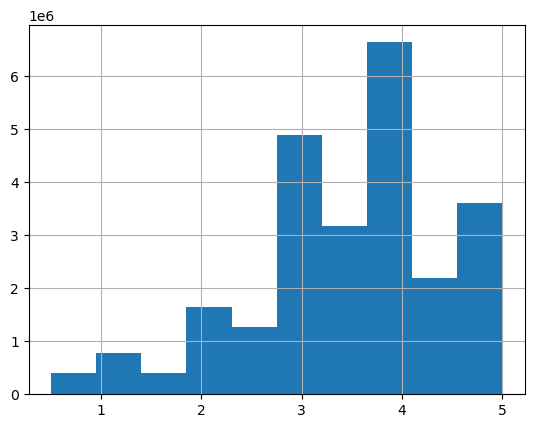

In [127]:
ratings['rating'].hist()

<Axes: >

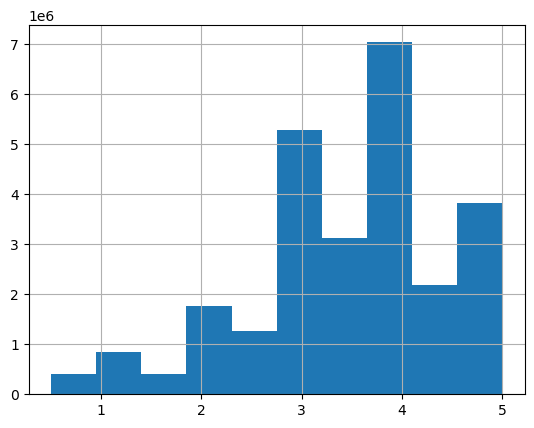

In [128]:
combined_ratings['rating'].hist()

In [129]:
!pip install cython numpy

Defaulting to user installation because normal site-packages is not writeable


In [131]:

from sklearn.decomposition import TruncatedSVD

In [132]:
combined_ratings.head()

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435
2,1,858,5.0,1425941523
3,1,1221,5.0,1425941546
4,1,1246,5.0,1425941556


In [133]:
combined_ratings.shape

(26124293, 4)

In [134]:

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

In [135]:
ratings = combined_ratings
ratings.head()

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435
2,1,858,5.0,1425941523
3,1,1221,5.0,1425941546
4,1,1246,5.0,1425941556


In [136]:
user_ids = ratings['userId'].astype('category')
movie_ids = ratings['movieId'].astype('category')

user_map = user_ids.cat.categories
movie_map = movie_ids.cat.categories

user_index = user_ids.cat.codes
movie_index = movie_ids.cat.codes

In [137]:
R = csr_matrix(
    (ratings['rating'], (user_index, movie_index))
)

In [138]:
svd = TruncatedSVD(n_components=80, random_state=42)
U = svd.fit_transform(R)

In [139]:
def recommend_ids(user_id, top_n=10):
    
    # get user index
    user_idx = np.where(user_map == user_id)[0][0]
    
    # user vector
    user_vector = U[user_idx]
    
    # predict scores
    scores = user_vector @ svd.components_
    
    # top movies
    top_idx = np.argsort(scores)[::-1][:top_n]
    
    # convert to movieIds
    recommended_movie_ids = movie_map[top_idx]
    
    return recommended_movie_ids

In [140]:
recommend_ids(1)

Index([858, 1221, 2959, 58559, 79132, 2762, 4226, 33794, 59315, 91529], dtype='int64')

In [141]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435
2,1,858,5.0,1425941523
3,1,1221,5.0,1425941546
4,1,1246,5.0,1425941556


In [142]:
print(new_df['movieId'].min()) 
print(new_df['movieId'].max())  

1.0
176279.0


In [143]:
print(ratings['movieId'].min())
print(ratings['movieId'].max())

1
176275


In [144]:
print(new_df['tmdbId'].min())
print(new_df['tmdbId'].max())

2
469172


In [145]:
print(new_df['imdbId'].min())
print(new_df['imdbId'].max())

1
7158814


In [146]:

movie_id_to_title = dict(zip(new_df.movieId, new_df.title))

In [147]:
def recommend_with_names(user_id, top_n=10):
    
    user_idx = np.where(user_map == user_id)[0][0]
    user_vector = U[user_idx]
    
    scores = user_vector @ svd.components_
    top_idx = np.argsort(scores)[::-1][:top_n]
    
    movie_ids = movie_map[top_idx]
    
    return [movie_id_to_title.get(mid, mid) for mid in movie_ids]

In [148]:
recommend_with_names(2)

['Jurassic Park',
 'The Fugitive',
 'Apollo 13',
 'Dances with Wolves',
 "Schindler's List",
 'Se7en',
 'Four Weddings and a Funeral',
 'Sense and Sensibility',
 'Terminator 2: Judgment Day',
 'Speed']

In [149]:

def weighted_ensemble_recommendation(svd_scores, content_scores, movie_ids, w1=0.5, w2=0.5, top_n=10):
    """
    Combine SVD + Content-based scores using weighted sum.
    """

    # Convert to numpy arrays
    svd_scores = np.array(svd_scores)
    content_scores = np.array(content_scores)

    # Normalize scores (VERY important)
    svd_scores = (svd_scores - svd_scores.min()) / (svd_scores.max() - svd_scores.min() + 1e-9)
    content_scores = (content_scores - content_scores.min()) / (content_scores.max() - content_scores.min() + 1e-9)

    # Weighted combination
    final_scores = (w1 * svd_scores) + (w2 * content_scores)

    # Get top indices
    top_indices = np.argsort(final_scores)[::-1][:top_n]

    # Map indices to movie names
    recommended_movies = [movie_ids[i] for i in top_indices]

    return recommended_movies, final_scores[top_indices]